<a href="https://colab.research.google.com/github/rachmi00/ACNEI-MAMBA-FILES/blob/main/ACNEI_MAMBA_Single_Neuron_Modelling_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single Neuron Models: From Biology to Equation

Original notebook by [Marcus Ghosh](https://profiles.imperial.ac.uk/m.ghosh/) & [Dan Goodman](https://neural-reckoning.org/), based on the [Neuro4ML](https://neuro4ml.github.io/) course and [TReND-CaMinA](https://github.com/trendinafrica/TReND-CaMinA) teaching materials.

Adapted and presented for the **ACNEI Mathematics for Brain Modelling (MAMBA) Workshop** by  
[**AbdelQader AlKilany**](https://neural-reckoning.org/abdelqader_alkilany.html)

**Session:** Single Neuron Models: From Biology to Equation  
**Date:** 23 September 2026  
**Duration:** 2 hours

This version preserves the original build → test → challenge structure and the original TReND-CaMinA data, while adding the biological and mathematical foundations requested for MAMBA.

## Session route

| Time | Activity |
|---|---|
| 0–5 min | Welcome; run setup while introducing the session |
| 5–15 min | Why models? Minimal neuron biology |
| 15–25 min | State, input, parameters, differential equations |
| 25–38 min | Integrate-and-fire model and playground |
| 38–55 min | Refractory period and leaky integrate-and-fire |
| 55–65 min | Dynamic threshold and adaptation |
| 65–76 min | Hodgkin–Huxley demonstration |
| 76–83 min | Compare models, limitations, and challenge setup |
| **83–113 min** | **TReND-data exploratory challenge** |
| 113–120 min | Share-out and take-home messages |

> **Instructor guardrail:** start the challenge by minute 83. If running late, skip stretch tasks rather than shortening the challenge.

## How we will work

For each idea:

1. **Predict** what should happen.
2. **Watch** a reference example.
3. **Play** with one or two marked values for a few minutes.
4. **Report** one observation in the main-room chat.
5. **Explain** it using the biology or equation.

The **Everyone** tasks require only changing values in working code. **Stretch** tasks invite more confident programmers to modify the implementation.

Every stage has a completed reference function. If your experimental code breaks, run the reference cell and continue with the class.

In [ ]:
# Setup: imports and access to the original TReND-CaMinA materials
import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
})

PURPLE = "#7e1e9c"
GREEN = "#1b7f79"
GOLD = "#d89216"
GREY = "#666666"
RED = "#c43c39"

# The override is useful for an existing local copy. Colab users need not set it.
repo_override = os.environ.get("ACNEI_TREND_REPO")
if repo_override:
    REPO_DIR = Path(repo_override)
else:
    base_dir = Path("/content") if "google.colab" in sys.modules else Path.cwd()
    REPO_DIR = base_dir / "TReND-CaMinA"

if not REPO_DIR.exists():
    print("Downloading the TReND-CaMinA teaching materials...")
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/trendinafrica/TReND-CaMinA.git",
         str(REPO_DIR)],
        check=True
    )

LESSON_DIR = REPO_DIR / "notebooks" / "Zambia25" / "11-Fri-CompNeuroIntro"
DATA_DIR = LESSON_DIR / "Data"

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Could not find the TReND data folder. Restart the runtime and rerun setup."
    )

print("Setup complete.")
print("Data folder:", DATA_DIR)

Setup complete.
Data folder: /content/TReND-CaMinA/notebooks/Zambia25/11-Fri-CompNeuroIntro/Data


# Part 1 — Why model a single neuron?

A biological neuron contains complex dendrites, many ion-channel types, thousands of synapses, intracellular chemistry, noise, and a developmental history. A model deliberately leaves details out.

Models allow us to:

- turn a verbal explanation into a testable prediction;
- make assumptions explicit;
- change one factor while holding others fixed;
- connect input current to voltage and spikes;
- discover when an explanation is insufficient.

A model is not a miniature complete neuron. It is a tool designed for a question.

### Main-room prediction

Which needs more biological detail?

1. Predicting spike times in a network of 100,000 neurons.
2. Predicting how a sodium-channel blocker changes an action potential.

There is no universally “best” model; there is a model appropriate to a question.

## Minimal biology: input → integration → output

| Structure | Simplified role |
|---|---|
| **Dendrites** | Receive synaptic inputs |
| **Soma** | Integrates their electrical effects |
| **Axon initial segment** | Common site of spike initiation |
| **Axon** | Carries the action potential |
| **Synaptic terminals** | Influence other cells |

The cell membrane separates charge. Synaptic input changes ion flow, producing current that changes **membrane potential**. If depolarisation is sufficiently strong, the neuron may generate a brief **action potential**, or spike.

Today we initially treat the neuron as a single point. We retain voltage over time but discard its spatial structure.

## What makes this a dynamical system?

A model contains:

| Part | In our neuron model |
|---|---|
| **State variable** | membrane potential $V(t)$ |
| **Input** | current $I(t)$ |
| **Parameters** | threshold, time constant, resistance |
| **Rule for change** | a differential equation |
| **Output** | voltage and spike times |

The derivative $dV/dt$ means the rate at which voltage is changing now. A computer approximates continuous change in small steps:

$$V_{n+1}=V_n+\Delta t\left(\frac{dV}{dt}\right)_n.$$

This is the forward Euler method.

### Thirty-second check

In a simulation, which of the following changes at every time step: $V$, $\tau$, or $\Delta t$? Which are parameters?

# Part 2 — Building the model

## Integrate-and-fire

Start with the idea that input current accumulates:

$$C_m\frac{dV}{dt}=I(t).$$

In the normalized implementation below, capacitance is absorbed into the units:

$$\frac{dv}{dt}=I(t).$$

Then impose event rules:

- if $v$ reaches threshold, record a spike;
- reset $v$ to baseline.

This model retains spike timing but does not reproduce the action-potential waveform.

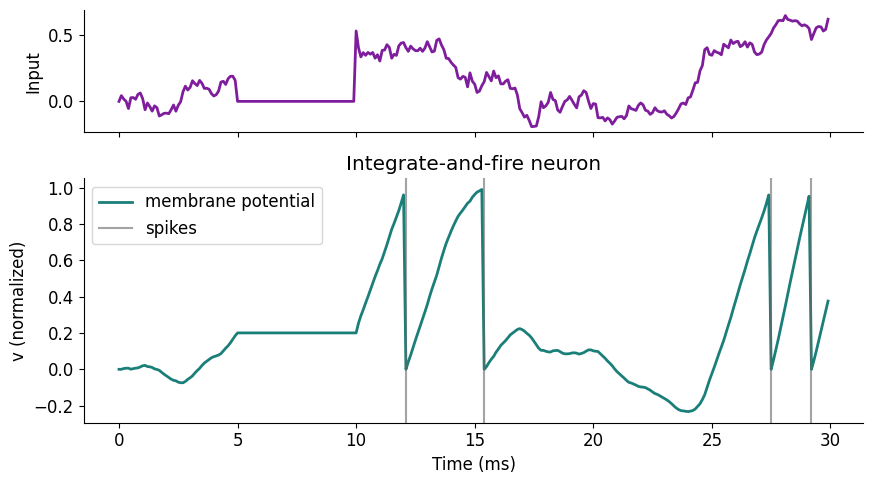

In [ ]:
def integrate_and_fire(I, baseline=0.0, threshold=1.0, dt=0.1):
    """Reference integrate-and-fire model in normalized units."""
    I = np.asarray(I, dtype=float)
    v = np.full(len(I), baseline, dtype=float)
    spikes = []

    for time in range(len(I) - 1):
        # Euler update for dv/dt = I(t)
        v[time + 1] = v[time] + I[time] * dt

        if v[time + 1] >= threshold:
            spikes.append((time + 1) * dt)
            v[time + 1] = baseline

    return v, np.asarray(spikes)

def plot_model_response(I, v, spikes, dt=0.1, title="Model response"):
    time = np.arange(len(I)) * dt
    fig, axes = plt.subplots(
        2, 1, sharex=True, figsize=(9, 5),
        gridspec_kw={"height_ratios": [1, 2]}
    )
    axes[0].plot(time, I, color=PURPLE, linewidth=2)
    axes[0].set_ylabel("Input")
    axes[1].plot(time, v, color=GREEN, linewidth=2,
                 label="membrane potential")
    for index, spike_time in enumerate(spikes):
        axes[1].axvline(
            spike_time, color=GREY, alpha=0.6,
            label="spikes" if index == 0 else None
        )
    axes[1].set(xlabel="Time (ms)", ylabel="v (normalized)", title=title)
    axes[1].legend(loc="best")
    plt.tight_layout()
    plt.show()

# Use the original TReND-CaMinA current.
test_current = np.loadtxt(DATA_DIR / "test_current.csv")
I_short = np.copy(test_current[0, :300])
I_short[50:100] = 0.0

v_if, spikes_if = integrate_and_fire(I_short)
plot_model_response(I_short, v_if, spikes_if,
                    title="Integrate-and-fire neuron")

### Exercise 1 — IF playground (4 minutes)

**Predict first**, then change one value at a time:

- Multiply input by 0.5, 2, or 5.
- Raise or lower threshold.

Questions:

1. What determines whether the model spikes?
2. What determines how quickly it reaches threshold?
3. When input becomes zero, what happens to a subthreshold voltage?
4. Is that last behaviour biologically plausible?

Put one result in the chat, for example: “Doubling input caused ___ because ___.”

**Stretch:** copy the reference function and add a capacitance parameter. Keep the supplied current sampled at 0.1 ms; changing the numerical time step fairly would require resampling that input.

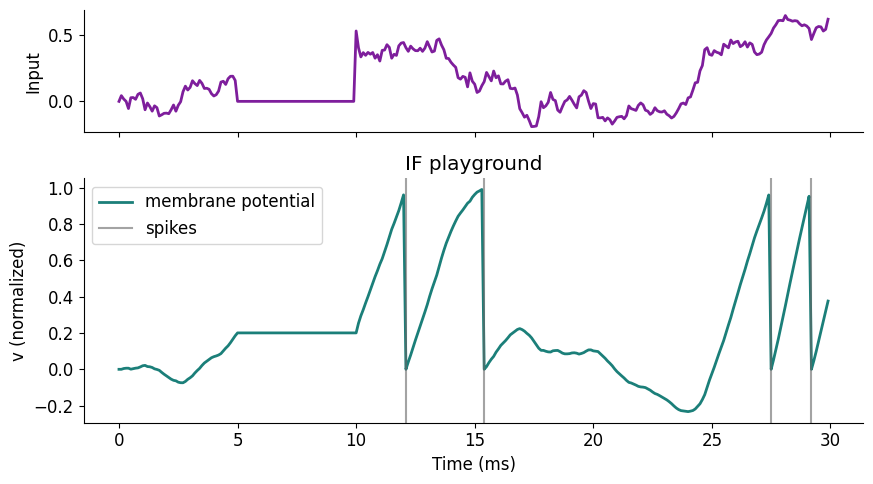

Number of spikes: 4


In [ ]:
# EVERYONE: edit these values and rerun.
input_scale = 1.0       # try 0.5, 2, or 5
if_threshold = 1.0      # try 0.7 or 1.5
v_play, spikes_play = integrate_and_fire(
    I_short * input_scale,
    threshold=if_threshold
)
plot_model_response(
    I_short * input_scale, v_play, spikes_play,
    dt=0.1, title="IF playground"
)
print("Number of spikes:", len(spikes_play))

## Adding a refractory period

After a biological spike, sodium channels need time to recover and potassium conductance remains elevated. During this refractory period, generating another spike is difficult or impossible.

Our simple model does not represent those channels, so we approximate the effect with a timer:

1. after a spike, start the timer;
2. while it is positive, hold voltage at baseline;
3. reduce the timer by $\Delta t$ at each step.

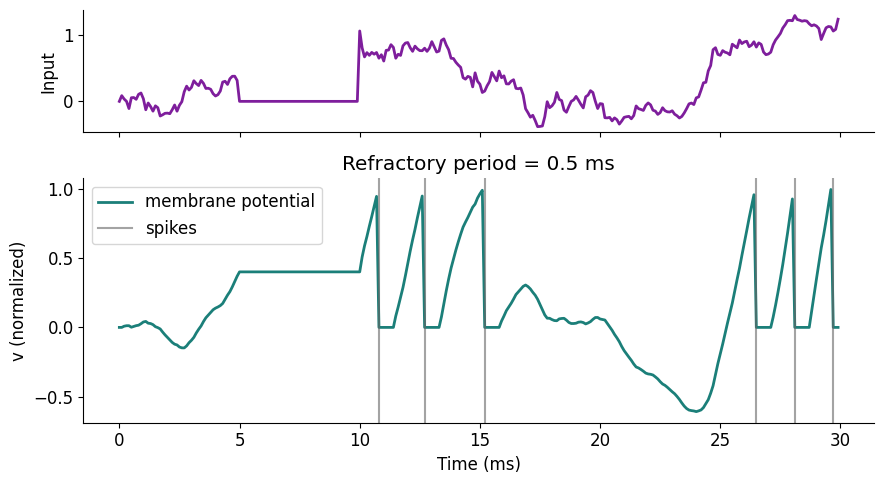

Number of spikes: 6


In [ ]:
def refractory_if(
    I, baseline=0.0, threshold=1.0, dt=0.1, refractory=0.5
):
    """Completed catch-up implementation: IF with refractoriness."""
    I = np.asarray(I, dtype=float)
    v = np.full(len(I), baseline, dtype=float)
    spikes = []
    refractory_left = 0.0

    for time in range(len(I) - 1):
        if refractory_left > 0:
            v[time + 1] = baseline
            refractory_left = max(0.0, refractory_left - dt)
            continue

        v[time + 1] = v[time] + I[time] * dt

        if v[time + 1] >= threshold:
            spikes.append((time + 1) * dt)
            v[time + 1] = baseline
            refractory_left = refractory

    return v, np.asarray(spikes)

# EVERYONE: try 0, 0.5, 2, and 5 ms.
refractory_duration = 0.5
v_ref, spikes_ref = refractory_if(
    I_short * 2, refractory=refractory_duration
)
plot_model_response(
    I_short * 2, v_ref, spikes_ref,
    title=f"Refractory period = {refractory_duration} ms"
)
print("Number of spikes:", len(spikes_ref))

### Exercise 2 — refractoriness (3 minutes)

Predict and test:

- What happens to the maximum possible firing rate as the refractory period grows?
- Can increasing input overcome an absolute refractory period in this model?
- What biological behaviour did we capture, and what did we simplify?

**Stretch:** instead of clamping voltage exactly to baseline, make it briefly hyperpolarise below baseline.

## Adding leak

A passive membrane stores charge like a capacitor but also loses current through open ion channels:

$$C_m\frac{dV}{dt}=-g_L(V-E_L)+I(t).$$

Using $R_m=1/g_L$ and $\tau_m=R_mC_m$:

$$\tau_m\frac{dV}{dt}=-(V-E_L)+R_mI(t).$$

For compatibility with the original normalized TReND exercise, take $E_L=0$ and absorb $R_m$ into the input:

$$\tau\frac{dv}{dt}=I(t)-v.$$

The new term $-v$ makes the neuron forget old input and return toward baseline.

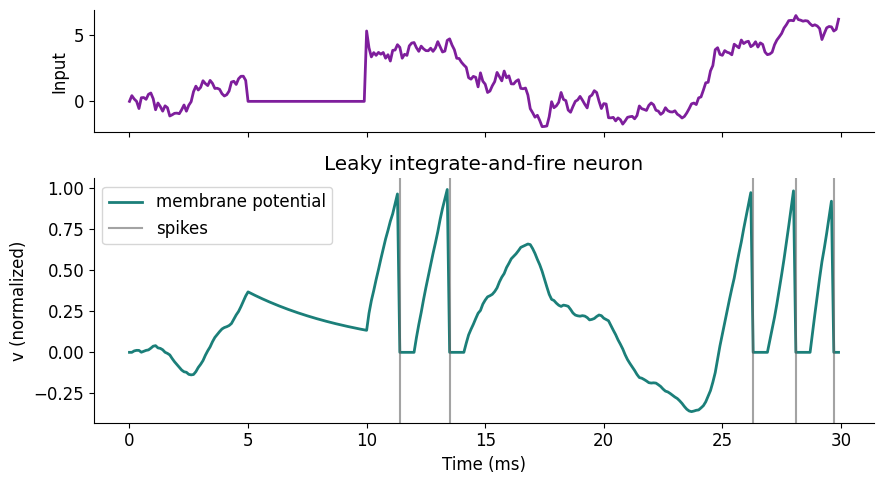

In [ ]:
def leaky_integrate_and_fire(
    I, baseline=0.0, threshold=1.0, dt=0.1,
    refractory=0.5, tau=5.0
):
    """Completed catch-up implementation: LIF in normalized units."""
    I = np.asarray(I, dtype=float)
    v = np.full(len(I), baseline, dtype=float)
    spikes = []
    refractory_left = 0.0

    for time in range(len(I) - 1):
        if refractory_left > 0:
            v[time + 1] = baseline
            refractory_left = max(0.0, refractory_left - dt)
            continue

        dvdt = (I[time] - (v[time] - baseline)) / tau
        v[time + 1] = v[time] + dvdt * dt

        if v[time + 1] >= threshold:
            spikes.append((time + 1) * dt)
            v[time + 1] = baseline
            refractory_left = refractory

    return v, np.asarray(spikes)

# The leak reduces voltage, so scale the original input for this display.
lif_input_scale = 10.0
v_lif, spikes_lif = leaky_integrate_and_fire(
    I_short * lif_input_scale, tau=5.0
)
plot_model_response(
    I_short * lif_input_scale, v_lif, spikes_lif,
    title="Leaky integrate-and-fire neuron"
)

### Exercise 3 — time constant playground (5 minutes)

The time constant controls how quickly voltage responds and how quickly it forgets. We temporarily disable spiking below so threshold and reset do not obscure the passive response.

Before running the cell, predict:

- Which responds faster: $\tau=2$ ms or $\tau=20$ ms?
- Which retains a brief input for longer?
- When input becomes zero, which trace returns toward baseline fastest?

Change the values and use the plot to explain your answer.

**Stretch:** copy the IF function and replace its update with the LIF differential equation yourself.

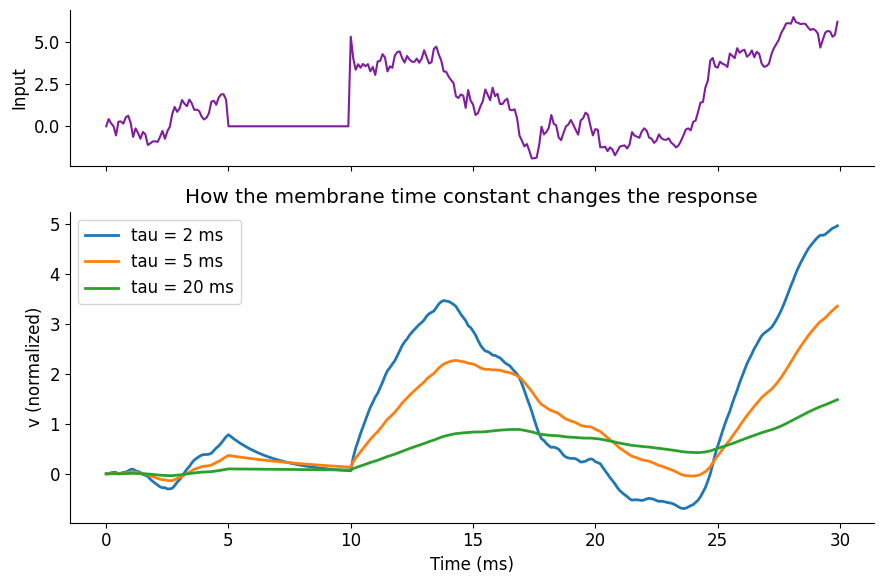

In [ ]:
# EVERYONE: compare several time constants with the same input.
tau_values = [2.0, 5.0, 20.0]
fig, axes = plt.subplots(
    2, 1, sharex=True, figsize=(9, 6),
    gridspec_kw={"height_ratios": [1, 2]}
)
axes[0].plot(np.arange(len(I_short)) * 0.1, I_short * 10,
             color=PURPLE)
axes[0].set_ylabel("Input")

for tau_value in tau_values:
    v_tau, _ = leaky_integrate_and_fire(
        I_short * 10, tau=tau_value, threshold=1e9
    )
    axes[1].plot(
        np.arange(len(v_tau)) * 0.1, v_tau,
        linewidth=2, label=f"tau = {tau_value:g} ms"
    )

axes[1].set(xlabel="Time (ms)", ylabel="v (normalized)",
            title="How the membrane time constant changes the response")
axes[1].legend()
plt.tight_layout()
plt.show()

## Adding a dynamic threshold

Many neurons adapt: under sustained input, their spikes gradually become farther apart.

We can represent a memory of recent firing with another state variable, the threshold $\theta(t)$:

$$\tau_\theta\frac{d\theta}{dt}=\theta_0-\theta.$$

After each spike:

$$\theta \leftarrow \theta+\Delta\theta.$$

This is an important modelling move: when one state variable is insufficient, add another state with a biological interpretation.

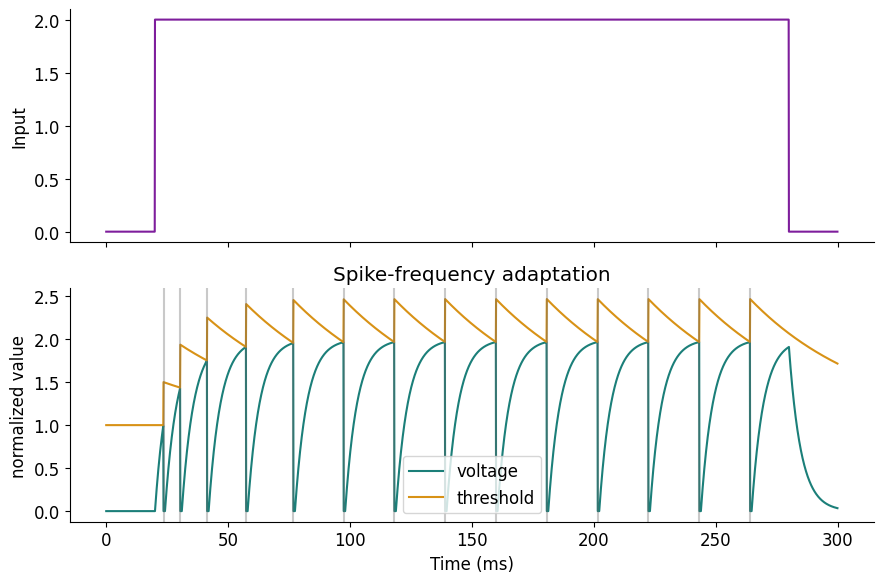

In [ ]:
def adaptive_lif(
    I, baseline=0.0, threshold=1.0, dt=0.1,
    refractory=0.5, tau=5.0,
    threshold_increment=0.5, threshold_tau=50.0
):
    """Completed catch-up implementation: LIF with adaptive threshold."""
    I = np.asarray(I, dtype=float)
    v = np.full(len(I), baseline, dtype=float)
    theta = np.full(len(I), threshold, dtype=float)
    spikes = []
    refractory_left = 0.0

    for time in range(len(I) - 1):
        # Threshold relaxes continuously toward its baseline.
        dthetadt = (threshold - theta[time]) / threshold_tau
        theta[time + 1] = theta[time] + dthetadt * dt

        if refractory_left > 0:
            v[time + 1] = baseline
            refractory_left = max(0.0, refractory_left - dt)
            continue

        dvdt = (I[time] - (v[time] - baseline)) / tau
        v[time + 1] = v[time] + dvdt * dt

        if v[time + 1] >= theta[time + 1]:
            spikes.append((time + 1) * dt)
            v[time + 1] = baseline
            theta[time + 1] += threshold_increment
            refractory_left = refractory

    return v, np.asarray(spikes), theta

# A constant input makes adaptation easy to see.
adapt_time = np.arange(0, 300, 0.1)
adapt_input = np.zeros_like(adapt_time)
adapt_input[(adapt_time >= 20) & (adapt_time < 280)] = 2.0

v_adapt, spikes_adapt, theta_adapt = adaptive_lif(
    adapt_input, threshold_increment=0.5, threshold_tau=50
)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
axes[0].plot(adapt_time, adapt_input, color=PURPLE)
axes[0].set_ylabel("Input")
axes[1].plot(adapt_time, v_adapt, color=GREEN, label="voltage")
axes[1].plot(adapt_time, theta_adapt, color=GOLD, label="threshold")
for spike_time in spikes_adapt:
    axes[1].axvline(spike_time, color=GREY, alpha=0.35)
axes[1].set(xlabel="Time (ms)", ylabel="normalized value",
            title="Spike-frequency adaptation")
axes[1].legend()
plt.tight_layout()
plt.show()

### Exercise 4 — adaptation playground (4 minutes)

Set the threshold increment to 0, 0.2, 0.5, and 1.

Then change the threshold time constant.

Questions:

1. Which parameter controls the immediate effect of a spike?
2. Which controls how long that effect lasts?
3. Why can a one-state LIF neuron not reproduce this history dependence?

Report one parameter change and its effect in the chat.

In [ ]:
# EVERYONE: edit and rerun.
adaptation_increment = 0.5  # try 0, 0.2, or 1
adaptation_tau = 50.0       # try 10 or 150 ms

v_play_adapt, spikes_play_adapt, theta_play = adaptive_lif(
    adapt_input,
    threshold_increment=adaptation_increment,
    threshold_tau=adaptation_tau
)

plt.plot(adapt_time, v_play_adapt, color=GREEN, label="voltage")
plt.plot(adapt_time, theta_play, color=GOLD, label="threshold")
for spike_time in spikes_play_adapt:
    plt.axvline(spike_time, color=GREY, alpha=0.3)
plt.xlabel("Time (ms)")
plt.ylabel("normalized value")
plt.title(f"Adaptive LIF: {len(spikes_play_adapt)} spikes")
plt.legend()
plt.show()

# Part 3 — Hodgkin–Huxley: making the spike emerge

IF and LIF impose a threshold and reset. Hodgkin–Huxley represents ionic currents:

$$C_m\frac{dV}{dt}
=I_{\mathrm{ext}}-I_{\mathrm{Na}}-I_{\mathrm{K}}-I_L.$$

For example:

$$I_{\mathrm{Na}}=\bar g_{\mathrm{Na}}m^3h(V-E_{\mathrm{Na}}),$$

$$I_{\mathrm{K}}=\bar g_{\mathrm{K}}n^4(V-E_{\mathrm{K}}).$$

Voltage changes the gating variables; the gates change the currents; the currents change voltage. This nonlinear feedback generates the action potential without an artificial reset.

The next cell is utility code. **Run it, but we will not derive every rate function.** Our goal is to understand what the extra mechanism allows us to ask.

In [ ]:
# Utility code: classic Hodgkin-Huxley point-neuron model.
def _safe_ratio(x, scale):
    if abs(x) < 1e-9:
        return scale
    return x / (1.0 - np.exp(-x / scale))

def _hh_rates(V):
    am = 0.1 * _safe_ratio(V + 40.0, 10.0)
    bm = 4.0 * np.exp(-(V + 65.0) / 18.0)
    ah = 0.07 * np.exp(-(V + 65.0) / 20.0)
    bh = 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))
    an = 0.01 * _safe_ratio(V + 55.0, 10.0)
    bn = 0.125 * np.exp(-(V + 65.0) / 80.0)
    return am, bm, ah, bh, an, bn

def simulate_hh(
    I_ext, dt=0.01, C_m=1.0, g_Na=120.0, g_K=36.0, g_L=0.3,
    E_Na=50.0, E_K=-77.0, E_L=-54.4, V0=-65.0
):
    I_ext = np.asarray(I_ext, dtype=float)
    time = np.arange(len(I_ext)) * dt
    V = np.empty(len(time))
    m = np.empty(len(time))
    h = np.empty(len(time))
    n = np.empty(len(time))
    V[0] = V0
    am, bm, ah, bh, an, bn = _hh_rates(V0)
    m[0], h[0], n[0] = am/(am+bm), ah/(ah+bh), an/(an+bn)

    for k in range(len(time) - 1):
        I_Na = g_Na * m[k]**3 * h[k] * (V[k] - E_Na)
        I_K = g_K * n[k]**4 * (V[k] - E_K)
        I_leak = g_L * (V[k] - E_L)
        dVdt = (I_ext[k] - I_Na - I_K - I_leak) / C_m

        am, bm, ah, bh, an, bn = _hh_rates(V[k])
        V[k + 1] = V[k] + dt * dVdt
        m[k + 1] = m[k] + dt * (am*(1-m[k]) - bm*m[k])
        h[k + 1] = h[k] + dt * (ah*(1-h[k]) - bh*h[k])
        n[k + 1] = n[k] + dt * (an*(1-n[k]) - bn*n[k])

    return time, V

hh_dt = 0.01
hh_time = np.arange(0, 70, hh_dt)
hh_input = np.zeros_like(hh_time)
hh_input[(hh_time >= 10) & (hh_time < 55)] = 10.0

hh_t, hh_control = simulate_hh(hh_input, dt=hh_dt)
_, hh_low_na = simulate_hh(hh_input, dt=hh_dt, g_Na=40.0)
_, hh_low_k = simulate_hh(hh_input, dt=hh_dt, g_K=12.0)

plt.plot(hh_t, hh_control, color=GREEN, linewidth=2, label="control")
plt.plot(hh_t, hh_low_na, color=GOLD, label="reduced sodium conductance")
plt.plot(hh_t, hh_low_k, color=PURPLE, label="reduced potassium conductance")
plt.xlabel("Time (ms)")
plt.ylabel("V (mV)")
plt.title("A mechanistic intervention in Hodgkin-Huxley")
plt.legend()
plt.show()

### Main-room interpretation

Tetrodotoxin blocks voltage-gated sodium channels; tetraethylammonium blocks many potassium channels.

- What changed when sodium conductance was reduced?
- What changed when potassium conductance was reduced?
- Could an ordinary LIF model answer this pharmacological question?
- Why might we still choose LIF when simulating a large network?

We changed the **mechanism**, not merely the appearance of the trace.

## Comparing the models

| Model | State variables | Spike mechanism | Strength | Main limitation |
|---|---:|---|---|---|
| IF | $v$ | imposed threshold/reset | transparent and cheap | no return toward rest |
| LIF | $v$ | imposed threshold/reset | efficient subthreshold dynamics | no spike waveform |
| Adaptive LIF | $v,\theta$ | threshold/reset with memory | captures firing-rate adaptation | mechanism remains abstract |
| Hodgkin–Huxley | $V,m,h,n$ | ionic dynamics | mechanistic action potentials | more parameters and computation |

All are point-neuron models. They omit spatial dendrites and axons. They also simplify synapses, channel diversity, noise, metabolism, plasticity, and differences between real cells.

The best model is the simplest one that answers the question **without removing the mechanism the question depends on**.

# Part 4 — Testing against the original TReND-CaMinA data

We now return to the original notebook's central idea: can our simple model reproduce spikes produced by a more complex “real” neuron?

The target is itself a simulation, not biological recording, but the modelling workflow is realistic:

1. inject the same current into target and candidate;
2. compare their spike times;
3. adjust the model using training data;
4. evaluate once on held-out test data.

This is where model limitations become experimentally visible.

In [ ]:
# Load the original train/test datasets.
train_I = np.loadtxt(DATA_DIR / "train_current.csv")
train_v = np.loadtxt(DATA_DIR / "train_traces.csv")
train_spike_times, train_spike_idx = np.loadtxt(DATA_DIR / "train_spikes.csv")

test_I = test_current
test_v = np.loadtxt(DATA_DIR / "test_traces.csv")
test_spike_times, test_spike_idx = np.loadtxt(DATA_DIR / "test_spikes.csv")

dt_data = 0.1
data_time = np.arange(train_I.shape[1]) * dt_data

def normalise(x):
    x = np.asarray(x)
    span = x.max() - x.min()
    return np.zeros_like(x) if span == 0 else (x - x.min()) / span

# Show five trials rather than ten to keep the display readable.
plt.figure(figsize=(10, 6))
for repeat in range(5):
    plt.plot(
        data_time, repeat + 0.85 * normalise(train_I[repeat]),
        color=PURPLE, alpha=0.75,
        label="input current" if repeat == 0 else None
    )
    plt.plot(
        data_time, repeat + 0.85 * normalise(train_v[repeat]),
        color=GREEN, alpha=0.75,
        label='target "neuron"' if repeat == 0 else None
    )
plt.xlabel("Time (ms)")
plt.ylabel("Training repeat")
plt.title("Original TReND-CaMinA training data")
plt.legend()
plt.tight_layout()
plt.show()

print("Training currents:", train_I.shape)
print("Test currents:", test_I.shape)

## Comparing spike trains

A perfect sample-by-sample match is too strict: spikes that differ by a fraction of a millisecond should be considered more similar than spikes separated by a long interval.

We therefore filter each spike train with a short exponential kernel and measure the distance between the resulting traces. This is a van Rossum-style spike distance.

- Smaller score = closer spike trains.
- The exact number is less important than comparing models consistently.
- Use training data while developing the model.
- Preserve test data for the final evaluation.

In [ ]:
def van_rossum_distance(t0, t1, duration, tau_vr=5.0, dt=0.1):
    """Causal exponentially filtered spike-train distance."""
    n = int(np.round(duration / dt))
    x0 = np.zeros(n)
    x1 = np.zeros(n)

    for trace, spike_times in [(x0, t0), (x1, t1)]:
        indices = np.rint(np.asarray(spike_times) / dt).astype(int)
        indices = indices[(indices >= 0) & (indices < n)]
        trace[indices] = 1.0

    kernel_time = np.arange(0, 5 * tau_vr, dt)
    kernel = np.exp(-kernel_time / tau_vr)
    x0_filtered = np.convolve(x0, kernel, mode="full")[:n]
    x1_filtered = np.convolve(x1, kernel, mode="full")[:n]

    return np.sqrt(
        np.sum((x0_filtered - x1_filtered)**2) * dt / tau_vr
    )

def evaluate_model(
    model_function, target_spike_times, target_spike_idx, input_currents,
    n_repeats=None, plot=True, max_plot_repeats=5, dt=0.1
):
    """Return mean spike distance for any function mapping current to (v, spikes)."""
    if n_repeats is None:
        n_repeats = input_currents.shape[0]
    n_repeats = min(n_repeats, input_currents.shape[0])
    duration = input_currents.shape[1] * dt
    distances = []

    if plot:
        plt.figure(figsize=(10, 4))

    for repeat in range(n_repeats):
        _, model_spikes = model_function(input_currents[repeat])
        target_spikes = target_spike_times[target_spike_idx == repeat]
        distances.append(
            van_rossum_distance(target_spikes, model_spikes, duration, dt=dt)
        )

        if plot and repeat < max_plot_repeats:
            plt.scatter(
                model_spikes, np.full(len(model_spikes), repeat),
                marker=".", color=GREEN,
                label="candidate model" if repeat == 0 else None
            )
            plt.scatter(
                target_spikes, np.full(len(target_spikes), repeat + 0.25),
                marker=".", color=PURPLE,
                label='target "neuron"' if repeat == 0 else None
            )

    if plot:
        plt.xlabel("Time (ms)")
        plt.ylabel("Repeat")
        plt.title("Target and candidate spike times")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return float(np.mean(distances))

# Part 5 — Exploratory challenge

**30 minutes, followed by a 7-minute share-out**

Build the simplest model you can that approximates the target spike trains. The supplied parameter values are intentionally weak: they produce some activity, but they are not recommended or pre-tuned.

### Level 1 — parameter explorer

Change only:

- input scale;
- leak time constant;
- threshold;
- refractory period;
- adaptation strength and time scale.

### Level 2 — mechanism explorer

Change or add a mechanism:

- hyperpolarising reset;
- noisy input or threshold;
- a different adaptation rule;
- a second time scale.

### Level 3 — fitting explorer

Write a loop or search procedure that evaluates several parameter combinations.

### Scientific workflow

1. State a prediction.
2. Change one thing.
3. Use the first **10 training repeats** for rapid feedback.
4. Record the score and what changed.
5. Do not use the test set until your final model.
6. Prefer an interpretable improvement over blind parameter guessing.

In [ ]:
# EDIT THIS CELL DURING THE CHALLENGE.
# These deliberately weak values leave clear room for improvement.
candidate_parameters = {
    "input_scale": 1.0,
    "threshold": 1.0,
    "tau": 5.0,
    "refractory": 0.5,
    "threshold_increment": 0.5,
    "threshold_tau": 50.0,
}

def candidate_model(I):
    scaled_I = I * candidate_parameters["input_scale"]
    v, spikes, _ = adaptive_lif(
        scaled_I,
        threshold=candidate_parameters["threshold"],
        tau=candidate_parameters["tau"],
        refractory=candidate_parameters["refractory"],
        threshold_increment=candidate_parameters["threshold_increment"],
        threshold_tau=candidate_parameters["threshold_tau"],
    )
    return v, spikes

# QUICK MODE: ten training repeats gives fast feedback.
quick_train_score = evaluate_model(
    candidate_model,
    train_spike_times,
    train_spike_idx,
    train_I,
    n_repeats=10,
    plot=True
)
print(f"Quick training score: {quick_train_score:.4f}")
print("Parameters:", candidate_parameters)

## Challenge prompts

If you are unsure what to try:

1. Does the candidate produce too many or too few spikes?
2. Are its spikes consistently too early or too late?
3. Does its performance vary across input patterns?
4. What happens if adaptation is removed by setting its increment to zero?
5. Can two different parameter combinations produce similar scores?
6. Does a better training score always mean a better scientific explanation?

Keep a small record:

| Change | Prediction | Training score | Observation |
|---|---|---:|---|
| Baseline | — | | |
| | | | |
| | | | |

In [ ]:
# FINAL EVALUATION: run this only after choosing your model.
full_train_score = evaluate_model(
    candidate_model,
    train_spike_times,
    train_spike_idx,
    train_I,
    n_repeats=None,
    plot=False
)
held_out_test_score = evaluate_model(
    candidate_model,
    test_spike_times,
    test_spike_idx,
    test_I,
    n_repeats=None,
    plot=True
)

print(f"Full training score: {full_train_score:.4f}")
print(f"Held-out test score: {held_out_test_score:.4f}")
print("Final parameters:", candidate_parameters)

## Share-out

Post these three things in the chat:

1. Your held-out test score.
2. The most important change you made.
3. One sentence explaining why you think it helped—or why it failed.

A low score is not the only success. A clear negative result can reveal that the model lacks an important state variable or mechanism.

# Take-home messages

1. Models simplify biology for a purpose.
2. Membrane potential is a state variable whose evolution can be described by a differential equation.
3. IF accumulates input; LIF also forgets through leak.
4. Refractoriness and adaptation add different kinds of biological constraint and memory.
5. HH explains action potentials through interacting ionic currents.
6. Simple and realistic are not opposites; they are choices along a question-dependent spectrum.
7. Models must be compared with data, tested outside the data used for development, and interpreted through their assumptions.
8. A model's failure can be scientifically useful.

## Sources and further reading

- Ghosh & Goodman — [Neuro4ML neuron structure](https://neuro4ml.github.io/neuron-structure), [function](https://neuro4ml.github.io/neuron-function), [abstract models](https://neuro4ml.github.io/abstract-models), and [biophysical models](https://neuro4ml.github.io/biophysical-models)
- [TReND-CaMinA teaching repository](https://github.com/trendinafrica/TReND-CaMinA)
- Gerstner et al. — [Neuronal Dynamics](https://neuronaldynamics.epfl.ch/)
- Hodgkin & Huxley (1952), *A quantitative description of membrane current and its application to conduction and excitation in nerve*
- van Rossum (2001), *A novel spike distance*